# Compare Runs

Side-by-side comparison of finished runs in `results/`: the full `metrics.csv` table (MAE / RMSE / Bias / Grad MAE / Pattern Corr / SSIM / IIEE / Spread-Error, per method) across as many runs as you like, plus one combined Taylor diagram overlaying every run's methods.

**Caveat:** Runs being compared here don't necessarily share a train/test split, domain, or even a data source -- some `results/` runs are FOSI (JRA55-forced, single-realization), others are older MESACLIP-ensemble runs (`Version3`-era). A lower RMSE on a different test period isn't automatically a better model; check each run's `description.txt` (or `run_config.json`, for runs that have one) before drawing conclusions.

**Data needed:**
- Table-metrics comparison only needs each run's top-level `metrics.csv`; works for every finished run.
- The Taylor diagram needs the cos(lat)-weighted correlation / std-ratio / centered-RMSE that `metrics.csv` doesn't carry (its `Pattern Corr` is unweighted -- see `evaluation_plots.ipynb` Section 11), so those are recomputed here directly from each run's `eval_data/fields.npz`, the same way `evaluation_plots.ipynb` does for a single run. Older runs that predate `eval_data/` (no `eval_data/` folder at all) are skipped for the Taylor diagram, with a note, but still show up in the table-metrics comparison.

In [1]:
import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## Config

In [18]:
RESULTS_FOLDER = "FOSI_daily_avg"
RESULTS_DIR = Path(f"/glade/work/skygale/_projects/SeaIceDownscaling/Version4/results/{RESULTS_FOLDER}/")

available_runs = sorted(d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and not d.name.startswith("."))
print(f"Available runs in results/{RESULTS_FOLDER}/:")
for r in available_runs:
    print(" ", r)

# Edit this list to pick a subset, defaults to comparing every available run
RUNS = available_runs

Available runs in results/FOSI_daily_avg/:
  FOSI_daily_2000-2005_2021_5501299.casper-pbs
  FOSI_daily_2005-2010_2021_5501300.casper-pbs
  FOSI_daily_2010-2015_2021_5501301.casper-pbs
  FOSI_daily_2015-2020_2021_5501302.casper-pbs


In [19]:
# Comparison figures/tables get saved here (mirrors the save_fig/save_table pattern in
# evaluation_plots.ipynb), namespaced under "run_comparison" rather than a single run name.
SAVE_DIR = Path("saved_figs") / "run_comparisons" / RESULTS_FOLDER
SAVE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to SAVE_DIR/<name>.png."""
    fig.savefig(SAVE_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


def save_table(df, name):
    """Save a table (DataFrame or Series) to SAVE_DIR/<name>.csv."""
    df.to_csv(SAVE_DIR / f"{name}.csv")


print("Saving comparison figures/tables to:", SAVE_DIR.resolve())

Saving comparison figures/tables to: /glade/work/skygale/_projects/SeaIceDownscaling/Version4/saved_figs/run_comparisons/FOSI_daily_avg


## 1. Table metrics across runs

Reads each run's top-level `metrics.csv` and stacks them into one long-format table tagged with
a `run` column. Runs missing `metrics.csv` (still training, or failed) are skipped with a note.

In [20]:
all_metrics = []
for run in RUNS:
    metrics_path = RESULTS_DIR / run / "metrics.csv"
    if not metrics_path.exists():
        print(f"Skipping {run}: no metrics.csv found (run may still be in progress).")
        continue
    df = pd.read_csv(metrics_path)
    df.insert(0, "run", run)
    all_metrics.append(df)

if not all_metrics:
    raise RuntimeError("No metrics.csv found for any selected run -- check RUNS/RESULTS_DIR above.")

all_metrics_df = pd.concat(all_metrics, ignore_index=True)
save_table(all_metrics_df, "00_all_metrics_long")
display(all_metrics_df)

,run,Method,MAE,RMSE,Bias,Grad MAE,Pattern Corr,SSIM,IIEE,Coastal MAE,Coastal RMSE,Spread/Error
0,FOSI_daily_2000-2005_2021_5501299.casper-pbs,Bilinear,0.1772,0.4464,0.0781,0.0945,0.8323,0.7699,0.0000,0.2564,0.4898,NaN
1,FOSI_daily_2000-2005_2021_5501299.casper-pbs,Deterministic UNet,0.0867,0.1980,-0.0032,0.0881,0.9338,0.8358,0.1551,0.1913,0.3342,NaN
2,FOSI_daily_2000-2005_2021_5501299.casper-pbs,Stochastic UNet Mean,0.0741,0.1827,-0.0031,0.0767,0.9479,0.8786,0.1251,0.1691,0.3097,1.7472
3,FOSI_daily_2005-2010_2021_5501300.casper-pbs,Bilinear,0.1772,0.4464,0.0781,0.0945,0.8323,0.7699,0.0000,0.2564,0.4898,NaN
4,FOSI_daily_2005-2010_2021_5501300.casper-pbs,Deterministic UNet,0.0899,0.2079,0.0042,0.0893,0.9299,0.8406,0.1833,0.2015,0.3520,NaN
5,FOSI_daily_2005-2010_2021_5501300.casper-pbs,Stochastic UNet Mean,0.0746,0.1867,-0.0072,0.0760,0.9402,0.8856,0.2080,0.1658,0.3165,1.8110
6,FOSI_daily_2010-2015_2021_5501301.casper-pbs,Bilinear,0.1772,0.4464,0.0781,0.0945,0.8323,0.7699,0.0000,0.2564,0.4898,NaN
7,FOSI_daily_2010-2015_2021_5501301.casper-pbs,Deterministic UNet,0.0878,0.1996,0.0038,0.0874,0.9343,0.8314,0.1211,0.1977,0.3343,NaN
8,FOSI_daily_2010-2015_2021_5501301.casper-pbs,Stochastic UNet Mean,0.0742,0.1844,-0.0029,0.0753,0.9435,0.8818,0.1261,0.1680,0.3097,1.6499
9,FOSI_daily_2015-2020_2021_5501302.casper-pbs,Bilinear,0.1772,0.4464,0.0781,0.0945,0.8323,0.7699,0.0000,0.2564,0.4898,NaN


In [21]:
# ---- Customize here ----
METRIC = "RMSE"   # any metrics.csv column: MAE, RMSE, Bias, Grad MAE, Pattern Corr, SSIM, IIEE, Spread/Error
# -------------------------

metric_slug = METRIC.replace(" ", "_").replace("/", "-")

pivot_df = all_metrics_df.pivot(index="run", columns="Method", values=METRIC)
save_table(pivot_df, f"01_{metric_slug}_by_run")
display(pivot_df)

Method,Bilinear,Deterministic UNet,Stochastic UNet Mean
run,,,
FOSI_daily_2000-2005_2021_5501299.casper-pbs,0.4464,0.1980,0.1827
FOSI_daily_2005-2010_2021_5501300.casper-pbs,0.4464,0.2079,0.1867
FOSI_daily_2010-2015_2021_5501301.casper-pbs,0.4464,0.1996,0.1844
FOSI_daily_2015-2020_2021_5501302.casper-pbs,0.4464,0.2244,0.1862


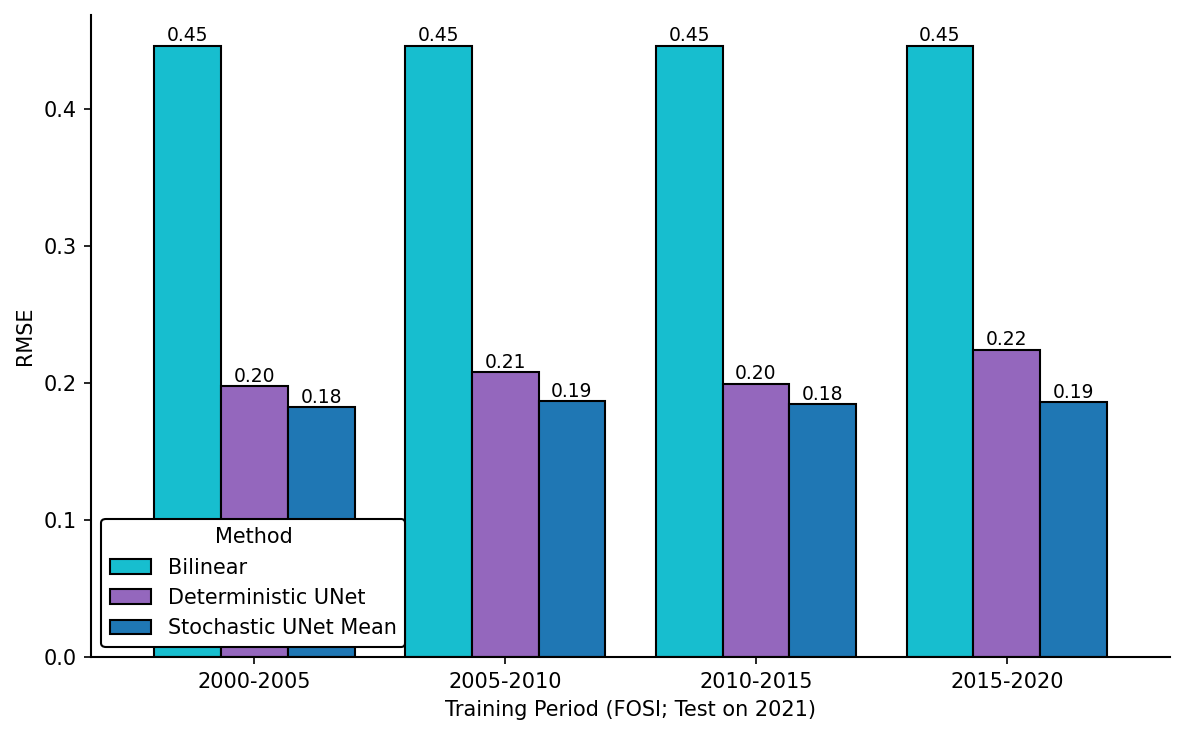

In [22]:
fig, ax = plt.subplots(figsize=(max(8, len(pivot_df)), 5), dpi=150)

pivot_df.plot(kind="bar", ax=ax, cmap="tab10_r", edgecolor="black", width=0.8)

ax.set_xticks(np.arange(len(pivot_df)))
run_names = []
for run_idx, run_name in enumerate(pivot_df.index):
    run_names.append(run_name[11:-24])
ax.set_xticklabels(run_names, rotation=45, fontsize=10)
ax.set_xlabel('Training Period (FOSI; Test on 2021)')
ax.set_ylabel(METRIC)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=0.1, fontsize=9)

ax.legend(fontsize=10, frameon=True, ncols=1, loc='lower left', facecolor='white', title="Method", framealpha=1, edgecolor='black')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

plt.xticks(rotation=0)
plt.tight_layout()

save_fig(fig, f"01_{metric_slug}_by_run")
plt.show()

## 2. Taylor diagram across runs

One combined Taylor diagram: every (run, method) pair as its own point, color-coded by run,
marker-shaped by method. Correlation / normalized std / centered RMSE are recomputed directly
from each run's `eval_data/fields.npz`, cos(lat)-weighted over ocean points only (same
`weighted_stats` logic as `evaluation_plots.ipynb` Section 11) -- `metrics.csv`'s `Pattern Corr`
is a *different*, unweighted number and isn't reused here.

Runs without an `eval_data/` folder (older, pre-`eval_data` runs) or with `use_patches=True`
(no single coherent grid to weight over) are skipped, with a printed note.

In [23]:
def weighted_stats(pred, truth, weight_hw):
    """Combined space+time weighted (R, std_ratio, centered_rmse): each sample weighted
    equally in time, each pixel weighted by weight_hw (land-masked, normalized to sum to 1)."""
    N = pred.shape[0]
    w = (weight_hw / N)[None, :, :]
    p, t = pred[:, 0], truth[:, 0]
    p_mean, t_mean = np.nansum(w * p), np.nansum(w * t)
    p_anom, t_anom = p - p_mean, t - t_mean
    var_p, var_t = np.nansum(w * p_anom ** 2), np.nansum(w * t_anom ** 2)
    cov = np.nansum(w * p_anom * t_anom)
    R = cov / np.sqrt(var_p * var_t)
    std_ratio = np.sqrt(var_p / var_t)
    crmse = np.sqrt(np.nansum(w * (p_anom - t_anom) ** 2))
    return float(R), float(std_ratio), float(crmse)


taylor_rows = []
for run in RUNS:
    eval_dir = RESULTS_DIR / run / "eval_data"
    if not eval_dir.exists():
        print(f"Skipping {run} for Taylor diagram: no eval_data/ (older run, predates saved fields).")
        continue

    with open(eval_dir / "meta.json") as f:
        meta = json.load(f)
    if meta["use_patches"]:
        print(f"Skipping {run} for Taylor diagram: use_patches=True (no single coherent grid).")
        continue

    fields = np.load(eval_dir / "fields.npz")
    mask_test = fields["mask_test"]
    Y_test_phys = fields["Y_test_phys"]
    land_hw = mask_test[0, 0] > 0.5

    with open(eval_dir / "tile_geometry.pkl", "rb") as f:
        tile_geometry = pickle.load(f)
    tgt_lat = tile_geometry[0]["target_lat"]
    tgt_lon = tile_geometry[0]["target_lon"]

    ocean_w_hw = np.where(land_hw, 0.0, np.cos(np.deg2rad(tgt_lat))[:, None] * np.ones((1, len(tgt_lon))))
    ocean_w_hw = ocean_w_hw / ocean_w_hw.sum()

    method_fields = {
        "Bilinear": fields["Y_base_phys"], "Deterministic UNet": fields["Y_pred_det_phys"],
        "Stochastic UNet Mean": fields["Y_pred_phys"],
    }
    for method_name, field in method_fields.items():
        R, std_ratio, crmse = weighted_stats(field, Y_test_phys, ocean_w_hw)
        taylor_rows.append({
            "run": run, "Method": method_name,
            "Correlation (R)": round(R, 4), "Std Ratio": round(std_ratio, 4),
            "Centered RMSE (m)": round(crmse, 4),
        })

if not taylor_rows:
    raise RuntimeError("No selected run has eval_data/ with use_patches=False -- nothing to plot.")

taylor_df = pd.DataFrame(taylor_rows)
save_table(taylor_df, "02_taylor_stats_by_run")
display(taylor_df)

,run,Method,Correlation (R),Std Ratio,Centered RMSE (m)
0,FOSI_daily_2000-2005_2021_5501299.casper-pbs,Bilinear,0.9547,0.9316,0.2978
1,FOSI_daily_2000-2005_2021_5501299.casper-pbs,Deterministic UNet,0.9738,0.9727,0.2271
2,FOSI_daily_2000-2005_2021_5501299.casper-pbs,Stochastic UNet Mean,0.9784,0.9757,0.2064
3,FOSI_daily_2005-2010_2021_5501300.casper-pbs,Bilinear,0.9547,0.9316,0.2978
4,FOSI_daily_2005-2010_2021_5501300.casper-pbs,Deterministic UNet,0.9704,0.9882,0.2415
5,FOSI_daily_2005-2010_2021_5501300.casper-pbs,Stochastic UNet Mean,0.9774,0.9789,0.2110
6,FOSI_daily_2010-2015_2021_5501301.casper-pbs,Bilinear,0.9547,0.9316,0.2978
7,FOSI_daily_2010-2015_2021_5501301.casper-pbs,Deterministic UNet,0.9730,0.9701,0.2304
8,FOSI_daily_2010-2015_2021_5501301.casper-pbs,Stochastic UNet Mean,0.9780,0.9713,0.2083
9,FOSI_daily_2015-2020_2021_5501302.casper-pbs,Bilinear,0.9547,0.9316,0.2978


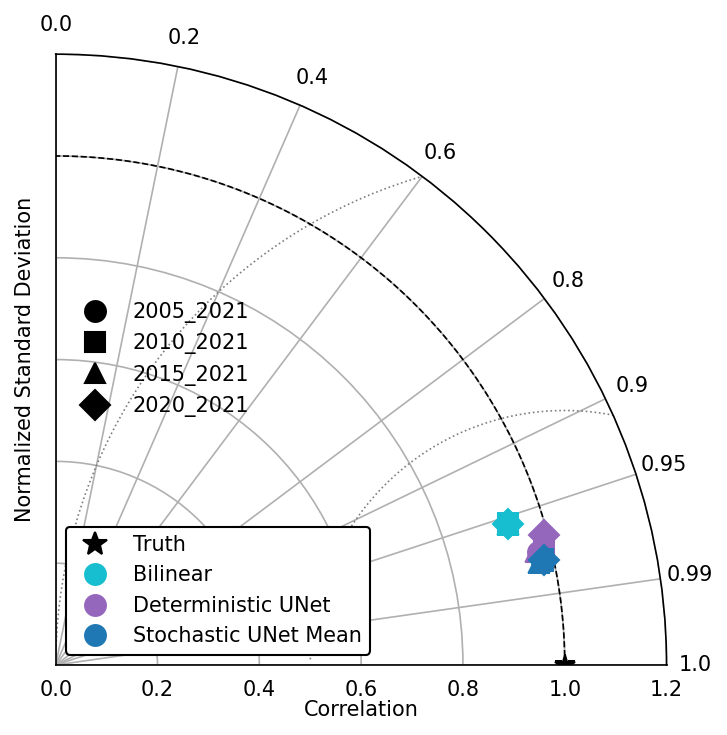

In [24]:
def rms_circle(center, radius, theta_lim=(0, np.pi / 2), n=200):
    t = np.linspace(0, 2 * np.pi, n)
    x, y = center[0] + radius * np.cos(t), center[1] + radius * np.sin(t)
    theta, r = np.arctan2(y, x), np.sqrt(x ** 2 + y ** 2)
    valid = (theta >= theta_lim[0]) & (theta <= theta_lim[1])
    return theta[valid], r[valid]


# Colors represent methods
method_list = taylor_df["Method"].unique().tolist()
cmap = plt.get_cmap("tab10_r") 
color_indices = [0, 5, 9]
METHOD_COLORS = {method: cmap(color_indices[i]) for i, method in enumerate(method_list)}

# Markers represent training periods
run_list = taylor_df["run"].unique().tolist()
marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*"]
RUN_MARKERS = {run: marker_cycle[i % len(marker_cycle)] for i, run in enumerate(run_list)}

max_std = taylor_df["Std Ratio"].max()
r_lim = 1.2

fig = plt.figure(figsize=(5, 5), dpi=150)
ax = fig.add_subplot(111, polar=True)
ax.set_thetamin(0)
ax.set_thetamax(90)
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)
ax.set_ylim(0, r_lim)

corr_ticks = np.array([0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0])
ax.set_xticks(np.arccos(corr_ticks))
ax.set_xticklabels([str(c) for c in corr_ticks])
ax.set_xlabel("Correlation", labelpad=12)
ax.set_ylabel("Normalized Standard Deviation", labelpad=2)

for rms in np.arange(0.5, r_lim, 0.5):
    th, r = rms_circle((1, 0), rms)
    ax.plot(th, r, color="gray", linestyle=":", linewidth=0.8)

std_circle_theta = np.linspace(0, np.pi / 2, 100)
ax.plot(std_circle_theta, np.ones_like(std_circle_theta), color="black", linestyle="--", linewidth=0.8)
ax.plot([0], [1], marker="*", color="black", markersize=10, linestyle="none", label="Truth")

for _, row in taylor_df.iterrows():
    R, std_ratio = row["Correlation (R)"], row["Std Ratio"]
    ax.plot(
        [np.arccos(np.clip(R, -1, 1))],
        [std_ratio],
        marker=RUN_MARKERS[row["run"]],
        markersize=10,
        color=METHOD_COLORS[row["Method"]],
        linestyle="none",
    )

# Training period (marker) legend
run_handles = [plt.Line2D([0], [0], marker=RUN_MARKERS[r], linestyle="none", color="black", markersize=10, label=r[16:-19]) for r in run_list]
legend1 = ax.legend(handles=run_handles, loc='center left', fontsize=10, frameon=False)
ax.add_artist(legend1)

# Method (color) legend
method_handles = [plt.Line2D([0], [0], marker="o", linestyle="none", color=METHOD_COLORS[m], markersize=10, label=m) for m in method_list]
method_handles.insert(0, plt.Line2D([0], [0], marker="*", linestyle="none", color="black", markersize=12, label="Truth"))

ax.legend(
    handles=method_handles,
    loc='lower left',
    fontsize=10,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
)

plt.tight_layout()
save_fig(fig, "02_taylor_diagram_comparison")
plt.show()